- X is independent variables maybe the house size
- y is dependent variables house price in thousands

In [15]:
x = [50, 60, 70, 80, 90] 
y = [150, 180, 210, 240, 270]  # house price in thousands 

In [16]:
import numpy as np
x = np.array(x)
y = np.array(y)

In [17]:
import matplotlib.pyplot as plt

class LinearRegressionGD:
    def __init__(self, eta =0.001, n_iters=100):
        self.eta = eta
        self.n_iters = n_iters
        self.theta_0 = 0.0  # Intercept -> bias
        self.theta_1 = 0.0  # Slope -> weight
        self.sse = []      # Sum of Squared Errors

    def fit(self, X, y):
        n = len(y)
        for _ in range(self.n_iters):
            # Calculate predictions
            y_pred = self.theta_0 + self.theta_1 * X    # y hat
            errors = y - y_pred
            
            # Update weights (using average gradient to prevent instant overflow)
            self.theta_1 += self.eta * (2/n) * np.sum(errors * X) ## delta L / delta w 
            self.theta_0 += self.eta * (2/n) * np.sum(errors) ## delta L / delta b
            
            # Calculate and store SSE
            sse = np.sum(errors ** 2)
            self.sse.append(sse)
        return self

    def predict(self, X):
        return self.theta_0 + self.theta_1 * X

    def plot_training(self, X, y):
        fig,ax = plt.subplots(1, 2, figsize=(12, 5))
        
        # Plot 1 SSE over iterations
        ax[0].plot(range(1, self.n_iters + 1), self.sse, marker='o', markersize=4)
        ax[0].set_xlabel('Iterations')
        ax[0].set_ylabel('Sum of Squared Errors (SSE)')
        ax[0].set_title('SSE over Iterations')
        
        # Plot 2 Reg Line
        ax[1].scatter(X, y, color='blue', label='Actual Data')
        ax[1].plot(X, self.predict(X), color='red', label='Regression Line')
        ax[1].set_xlabel('House Size')
        ax[1].set_ylabel('Price')
        ax[1].set_title('Regression Line Fitting')
        ax[1].legend()
        
        plt.tight_layout()
        plt.show()

- theta_0 is the Intercept -> b
- theta_1 is the Slope -> w

In [18]:
# instance of the model
model = LinearRegressionGD(eta=0.0001, n_iters=100)

# train the model
model.fit(x, y)

# print the learned values
print(f"theta_0 (Intercept or bias): {model.theta_0}")
print(f"theta_1 (Slope or weight): {model.theta_1}")

theta_0 (Intercept or bias): 0.04113676040970018
theta_1 (Slope or weight): 2.999435373457505


In [19]:
# predict for a 70 sqare house
size_to_predict = np.array([70])
predicted_price = model.predict(size_to_predict)

# print prediction
print(f"Predicted price for 70 sqare m: {predicted_price[0]} thousand")

Predicted price for 70 sqare m: 210.00161290243506 thousand


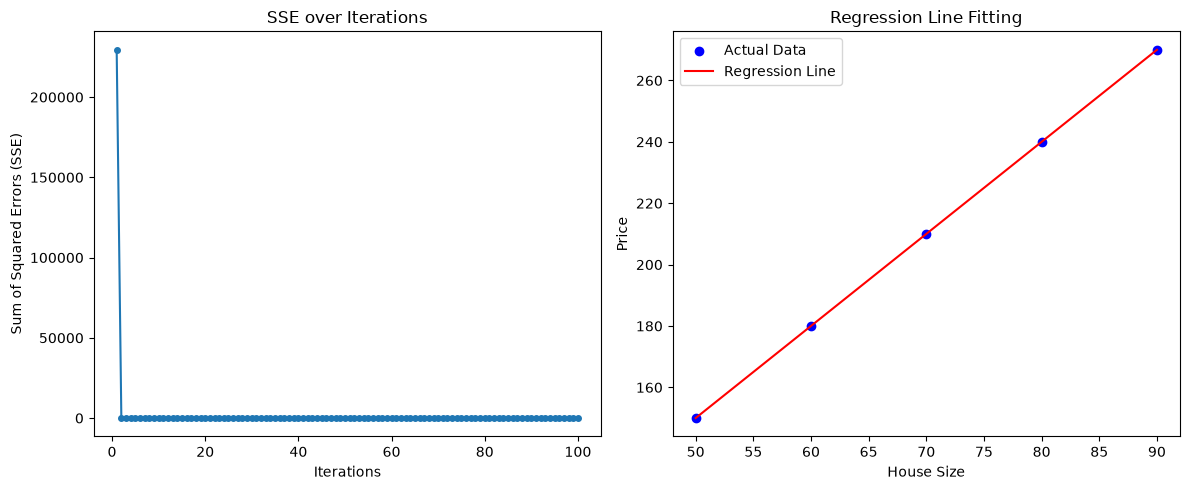

In [20]:
# visualize SSE and the regression line
model.plot_training(x, y)

- SSE decreases reason: theta0 and theta1 increase then y_pred increase so error decrease and sse uses sqared error so a big change happens each itration 

- convergence means that Gradient Descent has reached a point where the parameters are no longer changing significantly
- or we can say theta0 , theta1 values are stable and we maybe reached the glopal minimum

In [ ]:
model_slow = LinearRegressionGD(eta=0.000001, n_iters=100)
model_slow.fit(x, y)

In [ ]:
model_fast = LinearRegressionGD(eta=0.01, n_iters=100)
model_fast.fit(x, y)

C:\Users\hp\AppData\Local\Temp\ipykernel_14760\1317169549.py:23: RuntimeWarning: overflow encountered in square
  sse = np.sum(errors ** 2)


- in slow model it will learn slowly and sse decreases slowly
- in fast model it may learn faster but we may not reach global min and SSE decreases slowly then explodes and increase

In [ ]:
class AdvancedLinearRegressionGD:

    def __init__(self, eta=0.01, n_iters=1000, normalize=True):
        self.eta = eta
        self.n_iters = n_iters
        self.use_normalization = normalize
        self.weights = None
        self.bias = 0.0
        self.mse_ = []
        self.mean_ = None
        self.std_ = None

    def normalize(self, X):
        if self.mean_ is None:
            self.mean_ = np.mean(X, axis=0)
            self.std_ = np.std(X, axis=0)
            # Avoid division by zero
            self.std_[self.std_ == 0] = 1e-8
        return (X - self.mean_) / self.std_

    def fit(self, X, y):
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        # Normalize before training
        if self.use_normalization:
            X = self.normalize(X)
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        for _ in range(self.n_iters):
            # Prediction for multiple features
            y_pred = np.dot(X, self.weights) + self.bias
            # Calculate errors
            errors = y_pred - y
            # Update weights
            self.weights -= (self.eta
                * (1 / n_samples)
                * np.dot(X.T, errors))
            # Update bias
            self.bias -= (self.eta
                * (1 / n_samples)
                * np.sum(errors))
            # Calculate Mean Squared Error
            mse = np.mean(errors ** 2)
            self.mse_.append(mse)
        return self

    def predict(self, X):
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        if self.use_normalization:
            X = (X - self.mean_) / self.std_
        return np.dot(X, self.weights) + self.bias

    def plot_training(self, X, y):
            fig,ax = plt.subplots(1, 2, figsize=(12, 5))
            
            # Plot 1 MSE over iterations
            ax[0].plot(range(1, self.n_iters + 1), self.mse_, marker='o', markersize=4)
            ax[0].set_xlabel('Iterations')
            ax[0].set_ylabel('Mean Squared Errors (MSE)')
            ax[0].set_title('MSE over Iterations')
            
            # Plot 2 Reg Line
            ax[1].scatter(X, y, color='blue', label='Actual Data')
            ax[1].plot(X, self.predict(X), color='red', label='Regression Line')
            ax[1].set_xlabel('House Size')
            ax[1].set_ylabel('Price')
            ax[1].set_title('Regression Line Fitting')
            ax[1].legend()
            
            plt.tight_layout()
            plt.show()

In [49]:
x = [50, 60, 70, 80, 90] 
y = [150, 180, 210, 240, 270]
x = np.array(x,dtype=float)
y = np.array(y,dtype=float)
# instance of the model
model = AdvancedLinearRegressionGD(normalize=True)

model.fit(x, y)

print(f"bias: {model.bias}")
print(f"weight: {model.weights}")

bias: 209.99093403804375
weight: [42.42457527]


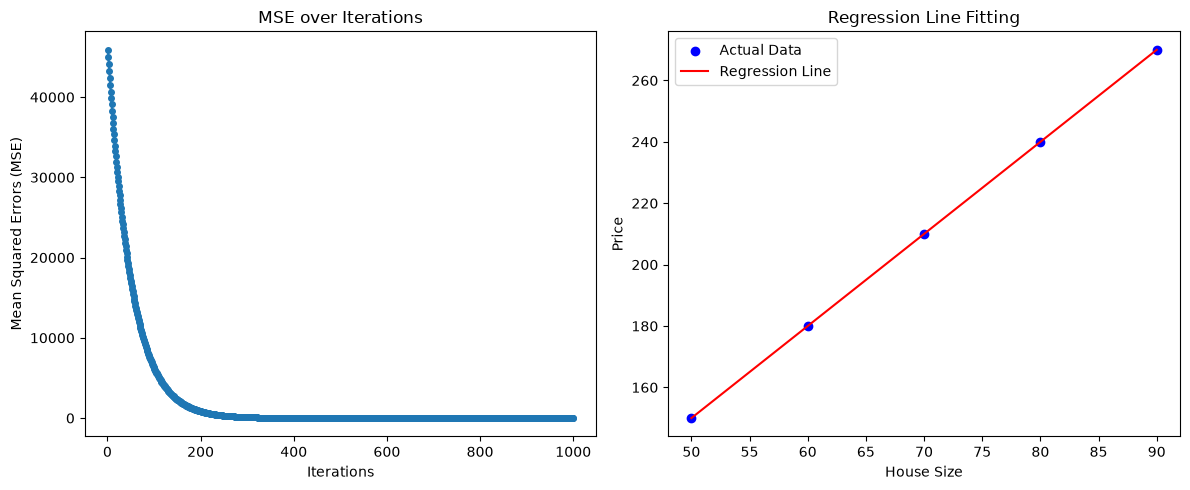

In [50]:
model.plot_training(x,y)